In [46]:
import numpy as np
from importlib import reload
import simulate_data as sim
reload(sim)
from gwas import gwas_linear, gwas_probit
from scipy.stats import norm

n, d = 1_000, 200
k = 10
corr = 0.7
rho = 0.5
snr_s = 1
snr_y = 2
pi_s = 0.1
pi_y = 0.05
p_sel = 0.3
rng = np.random.default_rng(42)

# LD matrix
R = sim.simulate_block_correlation_matrix(d, k, corr)

X = sim.simulate_design_matrix(n, R, intercept = False, rng = rng)

beta_s = sim.beta_heckman(d, R, pi_s, snr_s, rng)
beta_y = sim.beta_heckman(d, R, pi_y, snr_s, rng)

s, y, s_star, y_star =  heckman_outcome(X, beta_s, beta_y, sigma2_s, sigma2_y, p_sel, rho, rng = rng)

b_s = gwas_probit(X, s)[0] / np.sqrt(len(s))
b_y = gwas_linear(X, y)[0] / np.sqrt(s.sum())

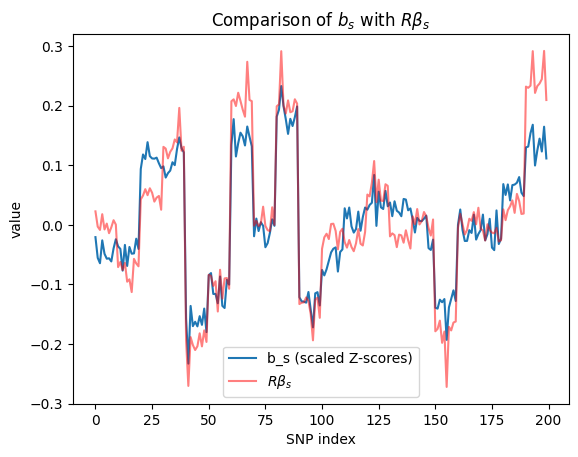

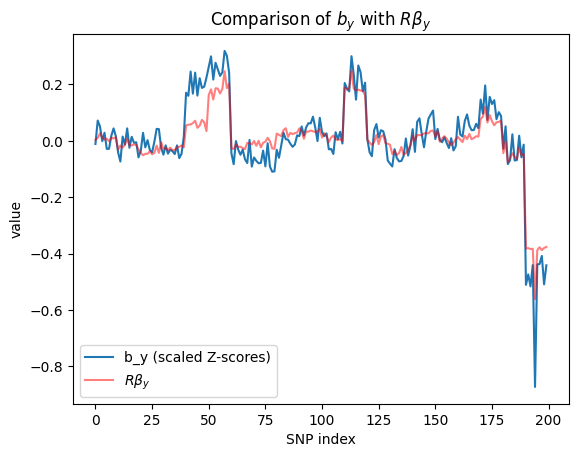

In [47]:
import matplotlib.pyplot as plt

R_hat = np.corrcoef(X, rowvar=False)
plt.plot(b_s, label="b_s (scaled Z-scores)")
plt.plot(R_hat @ beta_s , color="red", alpha=0.5, label=r"$R \beta_s$")
plt.legend()
plt.xlabel("SNP index")
plt.ylabel("value")
plt.title(r"Comparison of $b_s$ with $R\beta_s$")
plt.show()


plt.plot(b_y, label="b_y (scaled Z-scores)")
plt.plot(R_hat @ beta_y, color="red", alpha=0.5, label=r"$R \beta_y$")
plt.legend()
plt.xlabel("SNP index")
plt.ylabel("value")
plt.title(r"Comparison of $b_y$ with $R\beta_y$")
plt.show()

In [50]:
import numpy as np
from scipy.stats import norm

def inverse_mills_ratio(eta):
    log_lambda = norm.logpdf(eta) - norm.logcdf(eta)
    return np.exp(log_lambda)

eta = X @ beta_s
lam_eta = inverse_mills_ratio(eta)                  # shape (n,)
E_G_lambda = (X * lam_eta[:, None]).mean(axis=0)    # shape (d,)

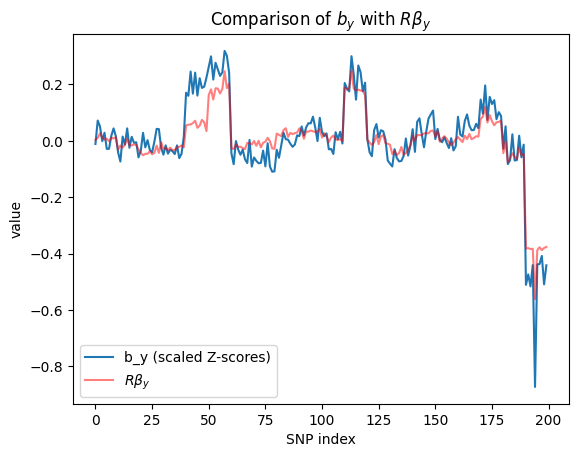

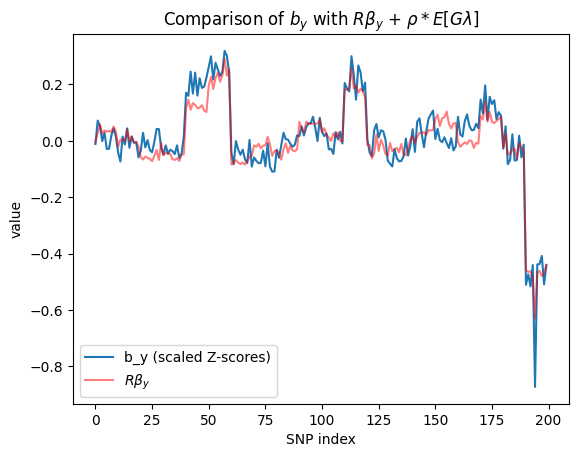

In [52]:
plt.plot(b_y, label="b_y (scaled Z-scores)")
plt.plot(R_hat @ beta_y, color="red", alpha=0.5, label=r"$R \beta_y$")
plt.legend()
plt.xlabel("SNP index")
plt.ylabel("value")
plt.title(r"Comparison of $b_y$ with $R\beta_y$")
plt.show()


plt.plot(b_y, label="b_y (scaled Z-scores)")
plt.plot(R_hat @ beta_y + rho*E_G_lambda , color="red", alpha=0.5, label=r"$R \beta_y$")
plt.legend()
plt.xlabel("SNP index")
plt.ylabel("value")
plt.title(r"Comparison of $b_y$ with $R\beta_y$ + $\rho*E[G \lambda]$")
plt.show()